In [1]:

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import joblib

from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

# =========================
# 1. قراءة الصور واستخراج HOG
# =========================

DATASET_PATH = r"C:\Users\LENOVO\Parknson proj\spiral\training"
IMAGE_SIZE = (128, 128)

features = []
labels = []

for label in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, label)

    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = cv2.resize(img, IMAGE_SIZE)

            hog_features = hog(
                img,
                orientations=9,
                pixels_per_cell=(8, 8),
                cells_per_block=(2, 2),
                block_norm="L2-Hys"
            )

            features.append(hog_features)
            labels.append(label)

        except Exception as e:
            print("Error loading:", img_path)

features = np.array(features)
labels = np.array(labels)

print("Features shape:", features.shape)

# =========================
# 2. Encoding labels
# =========================

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# =========================
# 3. Train / Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    features, labels_encoded, test_size=0.2, random_state=42, stratify=labels_encoded
)

# =========================
# 4. Random Forest Training
# =========================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# =========================
# 5. Evaluation
# =========================

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))


Features shape: (72, 8100)
Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

     healthy       1.00      0.88      0.93         8
   parkinson       0.88      1.00      0.93         7

    accuracy                           0.93        15
   macro avg       0.94      0.94      0.93        15
weighted avg       0.94      0.93      0.93        15



In [2]:
def predict_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, IMAGE_SIZE)

    hog_features = hog(
        img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    hog_features = hog_features.reshape(1, -1)

    pred = rf_model.predict(hog_features)
    return le.inverse_transform(pred)[0]


test_img = r"C:\Users\LENOVO\Parknson proj\spiral\training\healthy\V01HE02.png"
print(predict_image(test_img))



healthy


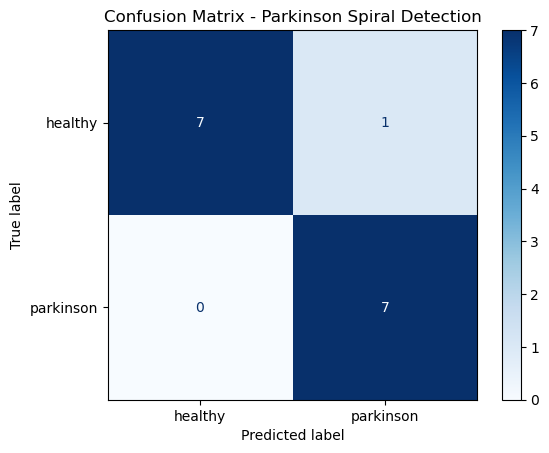


Model and LabelEncoder saved successfully ✅


In [3]:

# Confusion Matrix Plot
# =========================

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Parkinson Spiral Detection")
plt.show()

# =========================
# Save Model
# =========================

joblib.dump(rf_model, "parkinson_rf_model.pkl")
joblib.dump(le, "label_encoder.pkl")

print("\nModel and LabelEncoder saved successfully ✅")